# TARDIS - Model

My goal is to predict the expected delay in minutes for a given train using information known before departure.


In [52]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import metrics
from sklearn import compose
from sklearn import preprocessing
from sklearn import impute
from sklearn import pipeline
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

The cleaned dataset is loaded from the previous step

In [53]:
df = pd.read_csv("cleaned_dataset.csv", sep=";")
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,110.0,6.510000,44.0,8.0,36.134454,31.092437,10.924370,15.966387,5.040000,0.840336
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,32.0,5.363539,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,11.0,2.938053,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,39.0,5.292211,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,42.0,4.882372,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386


The target is the arrival delay in minutes

In [54]:
target = "Average delay of all trains at arrival"

df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target])

The date is transformed into simple features that can be known before the trip

In [55]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month

The model only uses information available before the train arrives.

In [ ]:
features = [
    "Service",
    "Departure station",
    "Arrival station",
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "year",
    "month",
]

df_model = df[features + [target]].copy()
df_model = df_model.dropna(subset=["Departure station", "Arrival station", target])

X = df_model[features]
y = df_model[target]

X.head()

,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,year,month
0,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,2018,1
1,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,2018,1
2,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,2018,1
3,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,2018,1
4,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,2018,1


We add preprocessing step before first training for up the data quality.

In [57]:
categorical_features = [
    "Service",
    "Departure station",
    "Arrival station",
]

numeric_features = [
    "Average journey time",
    "Number of scheduled trains",
    "Number of cancelled trains",
    "year",
    "month",
]

categorical_preprocessing = pipeline.Pipeline([
    ("fill_missing_values", impute.SimpleImputer(strategy="most_frequent")),
    ("convert_to_numbers", preprocessing.OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

numeric_preprocessing = pipeline.Pipeline([
    ("fill_missing_values", impute.SimpleImputer(strategy="median")),
])

preprocessor = compose.ColumnTransformer([
    (
        "categorical_columns",
        categorical_preprocessing,
        categorical_features,
    ),
    (
        "numeric_columns",
        numeric_preprocessing,
        numeric_features,
    ),
])

The dataset is split into training and testing data to compare the models on unseen trains

In [58]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((9148, 8), (2287, 8))

Each model is stored inside a pipeline with the same preprocessing step, this makes model comparison fair and keeps the final saved model easy to reuse

In [59]:
models = {
    "Baseline": pipeline.Pipeline([
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]),

    "DecisionTree": pipeline.Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        ))
    ]),

    "RandomForest": pipeline.Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=150,
            max_depth=14,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "ExtraTrees": pipeline.Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=150,
            max_depth=14,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": pipeline.Pipeline([
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=150,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        ))
    ])
}

The models are evaluated with MAE, RMSE and R². in minutes (order)

In [60]:
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = metrics.mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r2 = metrics.r2_score(y_test, predictions)

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
3,ExtraTrees,2.248368,4.139118,0.426605
4,HistGradientBoosting,2.155920,4.145438,0.424853
2,RandomForest,2.195509,4.171688,0.417546
1,DecisionTree,2.569099,4.865595,0.207663
0,Baseline,3.124073,5.466147,-0.000001


The charts below compares the models using precedent metrics 

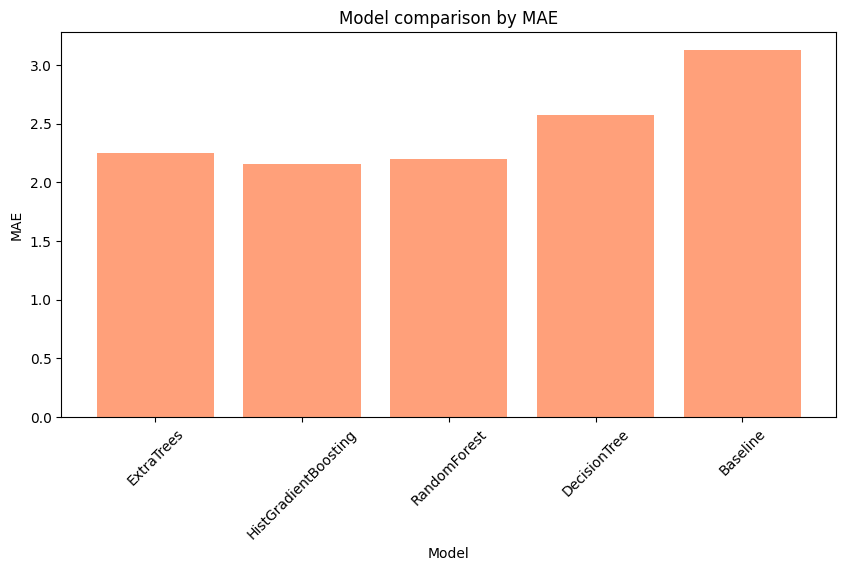

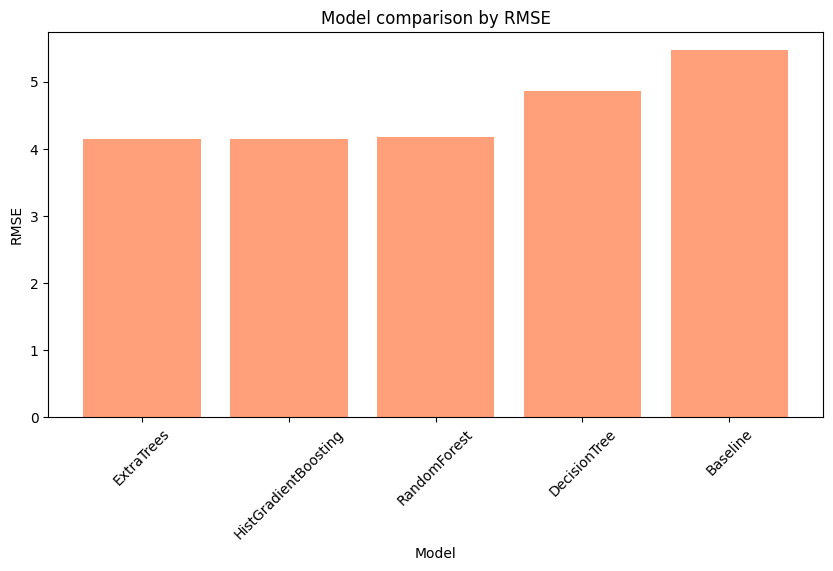

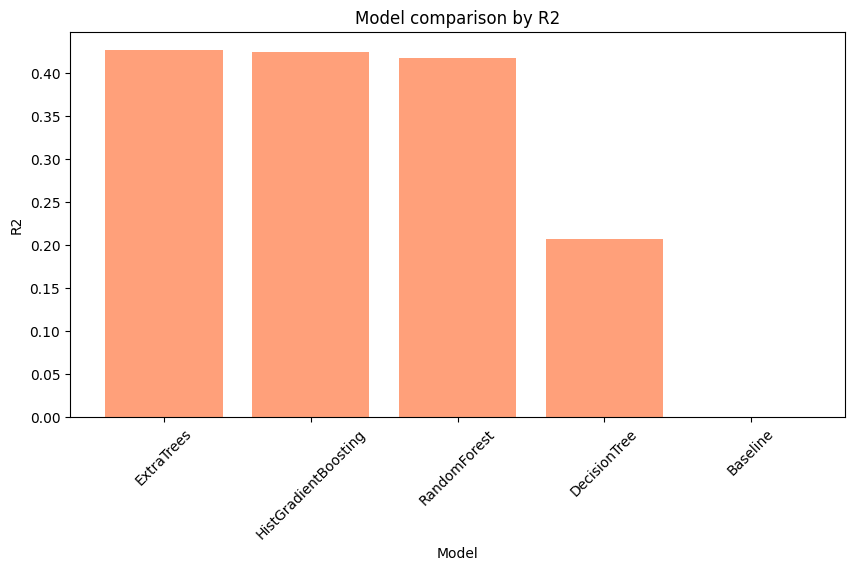

In [61]:
metrics_to_plot = ["MAE", "RMSE", "R2"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    plt.gca().set_facecolor("white")

    plt.bar(
        results_df["model"],
        results_df[metric],
        color="lightsalmon"
    )

    plt.title(f"Model comparison by {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.show()

The best model is selected from precedent metrics

In [62]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: ExtraTrees


A prediction example is made with one train (line) form dataset

In [63]:
sample_train = X_test.iloc[[0]]
real_delay = y_test.iloc[0]

predicted_delay = best_model.predict(sample_train)[0]

print("Predicted delay:", round(predicted_delay, 2), "minutes")
print("Real delay:", round(real_delay, 2), "minutes")

sample_train

Predicted delay: 6.22 minutes
Real delay: 9.55 minutes


,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,year,month
6588,National,PARIS MONTPARNASSE,VANNES,152.0,269.0,1.0,2022,7


After selecting the best model, it is trained again using the full dataset.

In [ ]:
final_model = models[best_model_name]
final_model.fit(X, y)

joblib.dump(final_model, "model.joblib")
results_df.to_csv("model_data.csv", index=False)

Saved model: model.joblib
Saved metrics: model_metrics.csv
Final model: ExtraTrees


The saved file `model.joblib` can now receive raw train information with the same feature names used in training and return a predicted delay in minutes

In [ ]:
example_train = pd.DataFrame([{
    "Service": X["Service"].iloc[0],
    "Departure station": X["Departure station"].iloc[0],
    "Arrival station": X["Arrival station"].iloc[0],
    "Average journey time": X["Average journey time"].iloc[0],
    "Number of scheduled trains": X["Number of scheduled trains"].iloc[0],
    "Number of cancelled trains": X["Number of cancelled trains"].iloc[0],
    "year": X["year"].iloc[0],
    "month": X["month"].iloc[0],
}])
loaded_model = joblib.load("model.joblib")
loaded_model.predict(example_train)[0]

np.float64(6.476292135922028)